# Aqui esta la historia de como se me fueron ocurriendo las cosas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [2]:
from scripts import style
style.mpl_apply()  

In [3]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

# Estandarizacion de la base de datos

En esta seccion se estandarizo la base de datos para que no haya alumnos repetidos que inflen la calificacion promedio de un profesor, o de una materia, etc. como los alumnos que revalidan materias y aparecen dos veces en la base de datos. Por ejemplo, yo salgo 2 veces en Calculo, 2 veces en Calculo II, etc.

In [4]:
print(materias.info())
materias.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27788 entries, 0 to 27787
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CLAVEALUMNO           27788 non-null  int64  
 1   CLAVECARRERA          27788 non-null  object 
 2   anio                  27788 non-null  int64  
 3   CLAVESESION           27788 non-null  object 
 4   NUMORDEN              27788 non-null  int64  
 5   CLAVEVARIANTEMATERIA  27788 non-null  object 
 6   DESCRIBEMATERIA       27788 non-null  object 
 7   CALIFICACION          27788 non-null  object 
 8   CLAVEPROFESOR         26740 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ MB
None


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0


Hay NaNs en los profes porque son de las revalidadas

In [5]:
def clean_materias_df(materias: pd.DataFrame) -> pd.DataFrame:
    # IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
    materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
    materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)

    # drop NUMORDEN column
    materias.drop(columns=['NUMORDEN'], inplace=True)

    # drop the rows where CLAVEPROFESOR is nan
    materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
    # make the CLAVEPROFESOR column integer
    materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)
    return materias

materias = clean_materias_df(materias)

In [6]:
materias.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152


In [7]:
def print_info():
    # clave profesor nunique
    profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
    profes_ids = materias['CLAVEPROFESOR'].unique()
    print(f'Número de profesores únicos: {len(profes_ids)}')
    print(f'Número de calificaciones: {len(materias)}')
    print(f'Máximo de calificaciones por profesor: {profes_value_counts.max()}')
    print(f'Mínimo de calificaciones por profesor: {profes_value_counts.min()}')
    print(f'Promedio de calificaciones por profesor: {profes_value_counts.mean():.2f}')
    print(f'Desviación estándar de calificaciones por profesor: {profes_value_counts.std():.2f}')
    print(f'Mediana de calificaciones por profesor: {profes_value_counts.median():.2f}')
    print('-----------------------------------')

    # clave alumno nunique
    number_of_students = materias['CLAVEALUMNO'].value_counts()
    print(f'Número de estudiantes únicos: {len(number_of_students)}')
    print(f'Máximo de calificaciones por estudiante: {number_of_students.max()}')
    print(f'Mínimo de calificaciones por estudiante: {number_of_students.min()}')
    print(f'Promedio de calificaciones por estudiante: {number_of_students.mean():.2f}')
    print(f'Desviación estándar de calificaciones por estudiante: {number_of_students.std():.2f}')
    print(f'Mediana de calificaciones por estudiante: {number_of_students.median():.2f}')
    print('-----------------------------------')

        
    carreras = materias['CLAVECARRERA'].value_counts()
    print("Carreras y número de calificaciones:")
    print(carreras)
    print('-----------------------------------')

    # get info from the years
    years = materias['anio'].value_counts().sort_index()
    print("Años y número de calificaciones:")
    print(years)

    return profes_value_counts, profes_ids

profes_value_counts, profes_ids = print_info()

Número de profesores únicos: 77
Número de calificaciones: 26140
Máximo de calificaciones por profesor: 969
Mínimo de calificaciones por profesor: 26
Promedio de calificaciones por profesor: 339.48
Desviación estándar de calificaciones por profesor: 226.34
Mediana de calificaciones por profesor: 327.00
-----------------------------------
Número de estudiantes únicos: 10413
Máximo de calificaciones por estudiante: 13
Mínimo de calificaciones por estudiante: 1
Promedio de calificaciones por estudiante: 2.51
Desviación estándar de calificaciones por estudiante: 1.44
Mediana de calificaciones por estudiante: 2.00
-----------------------------------
Carreras y número de calificaciones:
CLAVECARRERA
LAD     1909
LNI     1892
LII     1805
LMT     1488
LAT     1289
        ... 
BQI        1
BMT        1
LNMM       1
BNM        1
LADM       1
Name: count, Length: 99, dtype: int64
-----------------------------------
Años y número de calificaciones:
anio
2019    4260
2020    4724
2021    4856
2022

# Imputacion de valores faltantes

En esta seccion se prueban distintos metodos de imputacion de calificaciones

In [8]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float)
    k = 0
    # rejection sampling from KDE jitter
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        kept = draw[ok]
        take = min(len(kept), batch)
        if take:
            out[k:k+take] = kept[:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.5, min_kde_n=20, seed=42
):
    """
    Impute only NaNs in `value_col` by sampling a KDE fitted to observed values ≤ `high`.
    Observed values remain unchanged. Result in `out_col`.
    """
    rng = np.random.default_rng(seed)
    df = df.copy()

    # numeric projection
    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num  # start with numeric copy

    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df  # nothing to do

    obs_pre = num[~num.isna() & (num <= high)]
    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif len(obs_pre) > 0:
        draws = _sample_empirical(obs_pre.values, need, rng=rng)
        # ensure within bounds
        draws = np.clip(draws, low, high)
    else:
        # no support ≤ high; fallback constant within bounds
        draws = np.full(need, min(6.5, high), dtype=float)

    # assign only into NaNs
    df.loc[nan_mask, out_col] = draws
    # safety: clip only imputed entries (observed untouched)
    df.loc[nan_mask, out_col] = df.loc[nan_mask, out_col].clip(lower=low, upper=high)

    return df


# Pruebas de Hipotesis

In [9]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)


In [10]:
asesorias.head()

,fecha,id,carrera,semestre,profesor,materia,tema,periodo
0,2024-02-08 10:06:02,0,Ingeniería Mecánica,2,Daniela Rodríguez Tzompantzi,Cálculo I,Derivadas,P
1,2023-08-14 10:02:28,0,Física,3,Azucena Tochimani Tiro,Cálculo II,Sucesiones y series,O
2,2022-01-03 09:15:51,0,Psicología Clínica,2,DIEGO RODRIGUEZ CENTENO,Estadística Para Ciencias Sociales,Probabilidad,P
3,2021-03-19 20:36:13,0,Ingeniería Industrial,2,Miguel Pérez Gaspar,Cálculo I,Derivadas,P
4,2020-09-21 16:01:13,0,Ingeniería en Sistemas Computacionales,1,Anel Vázquez Martínez,Matemáticas Universitarias,Conceptos fundamentales algebra,O


# Numero de visitas al CMAT por estudiante 

In [11]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453,0
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897,0
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446,0
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149,0


Agregamos las visitas registradas al CMAT por id

In [12]:
def mala_imputacion_kde():
    # columns that define each "salón" (session)
    group_cols = ["CLAVEPROFESOR", "CLAVEVARIANTEMATERIA", "anio", "CLAVESESION"]

    # optionally filter to only the profesores we care about
    materias_sub = materias[materias["CLAVEPROFESOR"].isin(profes_ids)].copy()

    salones = {}

    def process_session(df):
        # Work on a copy to avoid SettingWithCopy warnings
        df = df.copy()

        # 1) Mean-imputation restricted to numeric <= 7.5
        numeric_calificaciones = pd.to_numeric(df["CALIFICACION"], errors="coerce")
        mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()

        df["IMPMEAN"] = numeric_calificaciones.fillna(mean_calificacion)

        # 2) Z-score of IMPMEAN within this group
        mean_imp = df["IMPMEAN"].mean()
        std_imp = df["IMPMEAN"].std()
        if std_imp == 0:
            # avoid division by zero; all equal -> z-score 0
            df["IMPMEAN_Z"] = 0.0
        else:
            df["IMPMEAN_Z"] = (df["IMPMEAN"] - mean_imp) / std_imp

        # 3) KDE-based imputation on CALIFICACION -> IMPKDE
        df = impute_nans_from_pre75_kde_df(
            df,
            value_col="CALIFICACION",
            out_col="IMPKDE"
        )

        # 4) Z-score of IMPKDE within this group
        mean_kde = df["IMPKDE"].mean()
        std_kde = df["IMPKDE"].std()
        if std_kde == 0:
            df["IMPKDE_Z"] = 0.0
        else:
            df["IMPKDE_Z"] = (df["IMPKDE"] - mean_kde) / std_kde

        return df

    # Group once over all (profesor, materia, anio, sesion)
    grouped = materias_sub.groupby(group_cols)

    for key, df_group in grouped:
        # key is (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION)
        sesion_materias = process_session(df_group)
        salones[key] = sesion_materias

    return salones

salones_mala = mala_imputacion_kde()

# Comparacion Global

In [13]:
ultramerge_mala = pd.concat(salones_mala.values(), ignore_index=True)

# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means_mala = ultramerge_mala.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means_mala.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means_mala = ultramerge_means_mala.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge_mala['CALIFICACION'] = pd.to_numeric(ultramerge_mala['CALIFICACION'], errors='coerce')


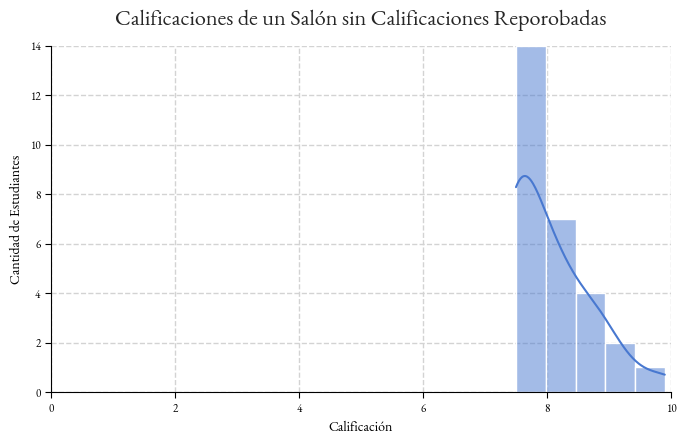

In [27]:
outlier_mala = salones_mala[(22115, 'MAT1052', 2024, 'PRIMAVERA')]

# plot impkde of outlier
sns.histplot(outlier_mala['IMPKDE'], bins=5, kde=True)
plt.title('Calificaciones de un Salón sin Calificaciones Reporobadas')
plt.xlabel('Calificación')
plt.ylabel('Cantidad de Estudiantes')
plt.xlim(0, 10)
plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
plt.savefig('visualizations/figuras/05_03.pdf', bbox_inches='tight')
plt.show()

# Esta mal la imputacion cuando no hay menos de 7.5!!! Corregir la imputacion

In [15]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df



def get_salones_with_imputations():
    salones = {}

    # group by the 4 keys instead of nested loops
    grouped = materias.groupby(
        ['CLAVEPROFESOR', 'CLAVEVARIANTEMATERIA', 'anio', 'CLAVESESION'],
        sort=False
    )

    for (prof_id, materia, anio, sesion), sesion_materias in grouped:
        # IMPORTANT: work on a copy so assignments are safe
        sesion_materias = sesion_materias.copy()

        # 1) mean-imputation truncated at 7.5
        numeric_calificaciones = pd.to_numeric(
            sesion_materias['CALIFICACION'], errors='coerce'
        )
        mean_calificacion = numeric_calificaciones[
            numeric_calificaciones <= 7.5
        ].mean()

        sesion_materias.loc[:, 'IMPMEAN'] = numeric_calificaciones.fillna(
            mean_calificacion
        )

        mean = sesion_materias['IMPMEAN'].mean()
        std = sesion_materias['IMPMEAN'].std()

        # avoid division by zero just in case
        if std == 0 or pd.isna(std):
            sesion_materias.loc[:, 'IMPMEAN_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPMEAN_Z'] = (
                sesion_materias['IMPMEAN'] - mean
            ) / std

        # 2) KDE-based imputation
        sesion_materias = impute_nans_from_pre75_kde_df(
            sesion_materias,
            value_col='CALIFICACION',
            out_col='IMPKDE',
            constant_value=6.5,
            fallback='uniform',
        )

        mean_kde = sesion_materias['IMPKDE'].mean()
        std_kde = sesion_materias['IMPKDE'].std()

        if std_kde == 0 or pd.isna(std_kde):
            sesion_materias.loc[:, 'IMPKDE_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPKDE_Z'] = (
                sesion_materias['IMPKDE'] - mean_kde
            ) / std_kde

        # store the processed DataFrame
        salones[(prof_id, materia, anio, sesion)] = sesion_materias

    return salones


salones = get_salones_with_imputations()

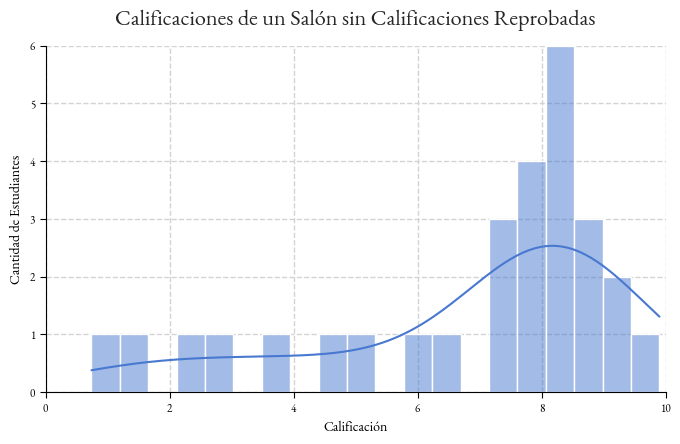

In [28]:
def plot_outlier_imputation_distribution(salones):
    outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
    # plot impkde of outlier
    sns.histplot(outlier['IMPKDE'], bins=20, kde=True)
    plt.title('Calificaciones de un Salón sin Calificaciones Reprobadas')
    plt.xlabel('Calificación')
    plt.ylabel('Cantidad de Estudiantes')
    plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
    plt.savefig('visualizations/figuras/05_04.pdf', bbox_inches='tight')
    plt.show()
plot_outlier_imputation_distribution(salones)

In [17]:
salon = salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')]
salon['CALIFICACION'] = pd.to_numeric(salon['CALIFICACION'], errors='coerce')

ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means = ultramerge.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means = ultramerge_means.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')
# ultramerge_means.sort_values(by='MEAN_IMPKDE_Z', ascending=False).head(10)

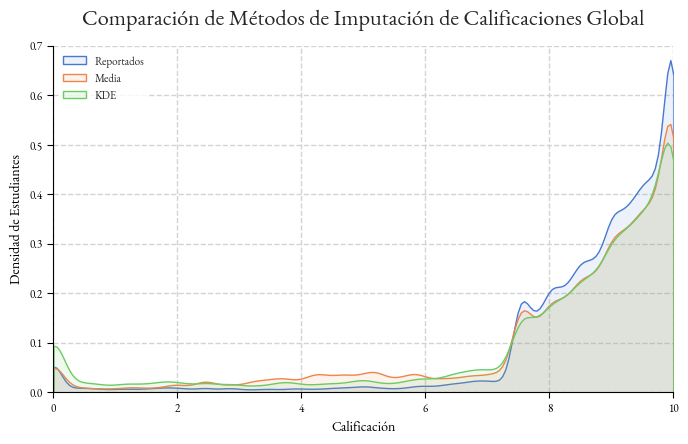

In [29]:

def comparacion_metodos_imputacion_calificaciones_global():
    sns.kdeplot(ultramerge['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, label='Reportados', linewidth=1, alpha=0.1)
    sns.kdeplot(ultramerge['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, label='Media', linewidth=1, alpha=0.1)
    sns.kdeplot(ultramerge['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, label='KDE', linewidth=1, alpha=0.1)
    plt.title('Comparación de Métodos de Imputación de Calificaciones Global')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad de Estudiantes')
    plt.legend()
    plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison_estandarizada.png', bbox_inches='tight')
    plt.savefig('visualizations/figuras/05_05.pdf', bbox_inches='tight')
    plt.show()

comparacion_metodos_imputacion_calificaciones_global()

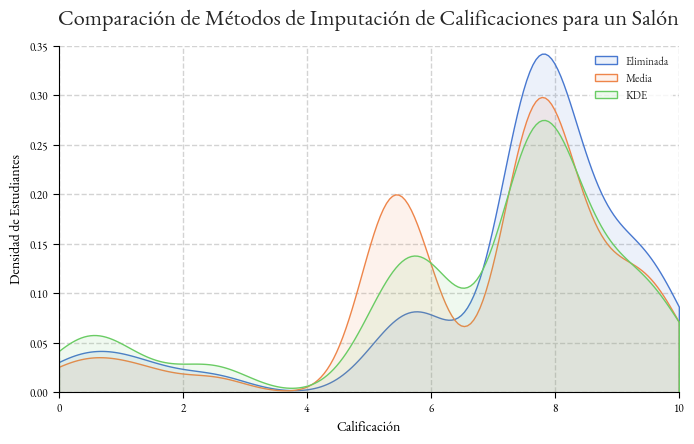

In [30]:

def comparacion_metodos_imputacion_calificaciones_salon(salon):
    sns.kdeplot(salon['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, alpha=0.1, label='Eliminada', linewidth=1)
    sns.kdeplot(salon['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, alpha=0.1, label='Media', linewidth=1)
    sns.kdeplot(salon['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, alpha=0.1, label='KDE', linewidth=1)
    plt.title('Comparación de Métodos de Imputación de Calificaciones para un Salón')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad de Estudiantes')
    plt.legend()
    plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison.png', bbox_inches='tight')
    plt.savefig('visualizations/figuras/05_01.pdf', bbox_inches='tight')
    plt.show()

comparacion_metodos_imputacion_calificaciones_salon(salon)

In [20]:
ultramerge.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,0,5.355,-0.639014,0.5,-2.346103
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.5,-2.346103
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.3,-0.513402
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.5,0.326586
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.8,0.441130
